In [ ]:
# ON HPC

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.qvalue.cis_qtl.txt.gz') 
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/Endothelial.qvalue.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/Endothelial.cis_qtl_pairs.chr.qvalue.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.sig.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/Endothelial.cis_qtl_pairs.chr.qvalue.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Bulk')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.qvalue.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        chr.res <- vroom(paste0(indir,'tsv.test/',cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        ct.res <- rbind(ct.res, chr.res)
        gc()
    }
    
    write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.tsv'),
           sep='\t', col.names=T, row.names=F, quote=F)
    write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.sig.tsv'),
               sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
    message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
    
    summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'H3K27acQTL.summary.tsv'),
           quote=F, row.names=F, col.names=T, sep='\t')

In [1]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/H3K27acQTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<int>,<int>
Endothelial,105649,33,411121303,1653
Hepatocytes,262182,370,1018657805,19948
T,16377,1,61851248,29
HSC,45585,0,176151028,0
Cholangiocyte,63689,0,249920083,0
Myeloid,112699,14,437918020,697
NK,9380,0,35207383,0
B,13278,0,49740291,0
Bulk,379410,442,1493678770,23448


In [4]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [5]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

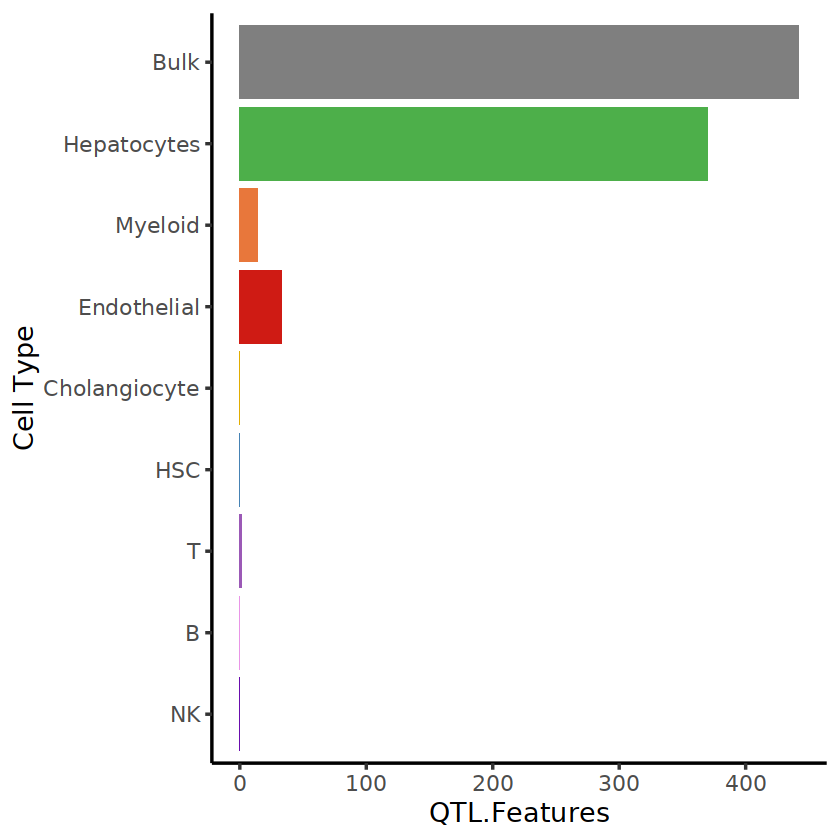

In [6]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='QTL.Features', y='Cell Type') + theme(legend.position="none")

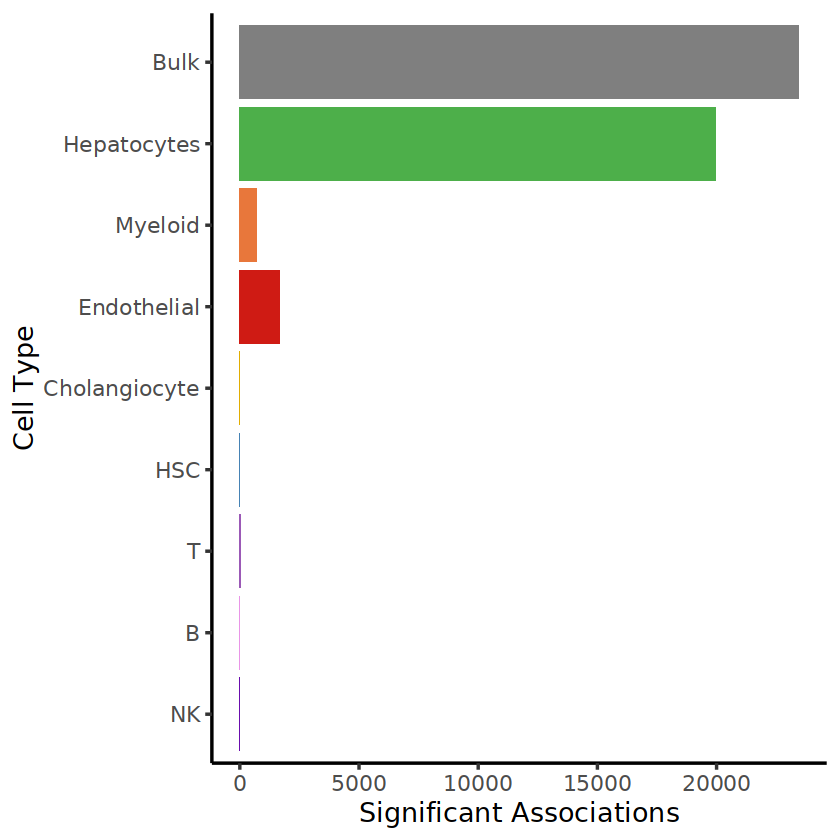

In [8]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")

# TMM

In [ ]:
# ON HPC

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.cis_qtl.txt.gz') 
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/tmm.outs/Endothelial.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/tmm.outs/Endothelial.cis_qtl_pairs.chr.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/tmm.outs/Endothelial.cis_qtl_pairs.chr.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/tmm.outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/tmm.outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Bulk')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        chr.res <- vroom(paste0(indir,'',cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        ct.res <- rbind(ct.res, chr.res)
        gc()
    }
    
    write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv'),
           sep='\t', col.names=T, row.names=F, quote=F)
    write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv'),
               sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
    message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
    
    summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'H3K27acQTL.summary.tsv'),
d           quote=F, row.names=F, col.names=T, sep='\t')

In [1]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/tmm.outs/H3K27acQTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<int>,<int>
Endothelial,105649,19,411121303,846
Hepatocytes,262182,297,1018657805,21797
T,16377,0,61851248,0
HSC,45585,0,176151028,0
Cholangiocyte,63689,1,249920083,72
Myeloid,112699,10,437918020,541
NK,9380,0,35207383,0
B,13278,0,49740291,0
Bulk,379410,320,1493678770,19741


In [3]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [4]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

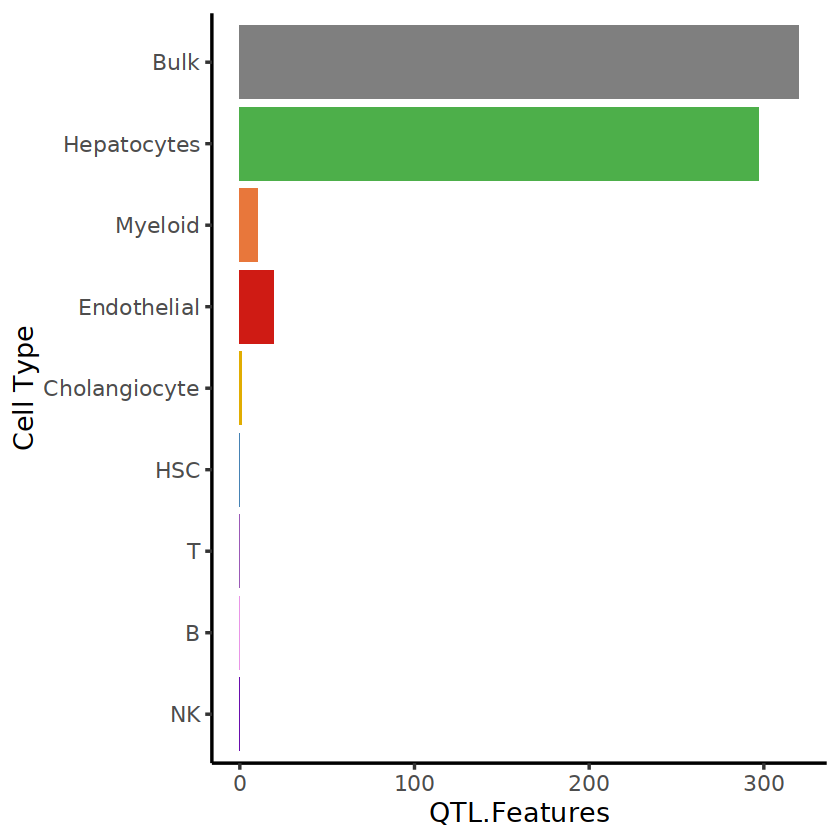

In [5]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='QTL.Features', y='Cell Type') + theme(legend.position="none")

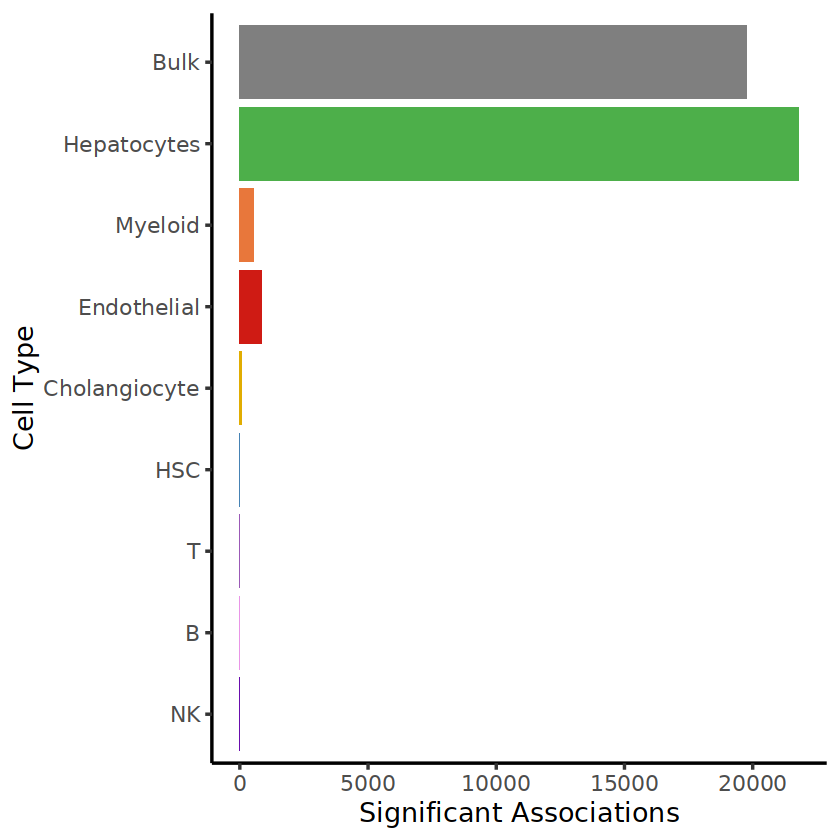

In [6]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")

# ATAC

In [ ]:
for parq in *.parquet; do parquet-tools csv $parq | sed 's|,|\t|g' > $parq.tsv; done

In [ ]:
# ON HPC

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.cis_qtl.txt.gz') 
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/Endothelial.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/Endothelial.cis_qtl_pairs.chr.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/Endothelial.cis_qtl_pairs.chr.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/ATAC.Peaks/outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/ATAC.Peaks/outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'HSC', 'Cholangiocyte', 'Myeloid', 'T')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        if (!file.exists(paste0(indir,cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'))) {
            next
        }
        chr.res <- vroom(paste0(indir,cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        ct.res <- rbind(ct.res, chr.res)
        gc()
    }
    
    write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv'),
           sep='\t', col.names=T, row.names=F, quote=F)
    write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv'),
               sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
    message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
    
    summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'H3K27acQTL.summary.tsv'),
           quote=F, row.names=F, col.names=T, sep='\t')

In [1]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [6]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/ATAC.Peaks/outs/H3K27acQTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<int>,<int>
Endothelial,14436,0,54812344,0
Hepatocytes,68708,73,266679722,3478
HSC,224,0,854404,0
Cholangiocyte,3575,1,13888054,65
Myeloid,10157,2,38568395,57
T,17,0,58844,0


In [7]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [8]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

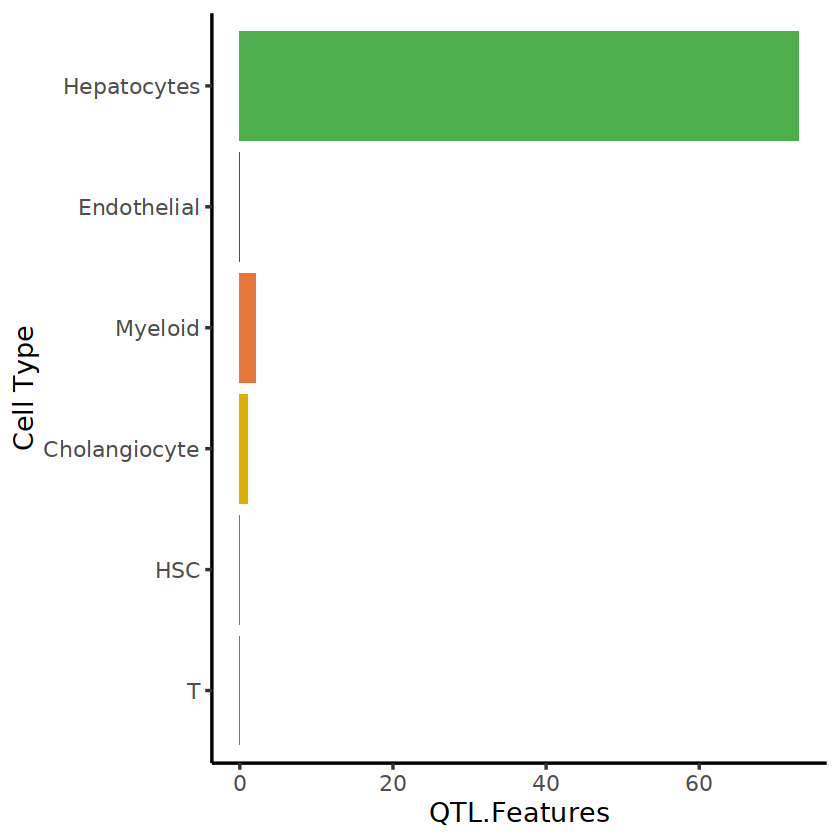

In [9]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='QTL.Features', y='Cell Type') + theme(legend.position="none")

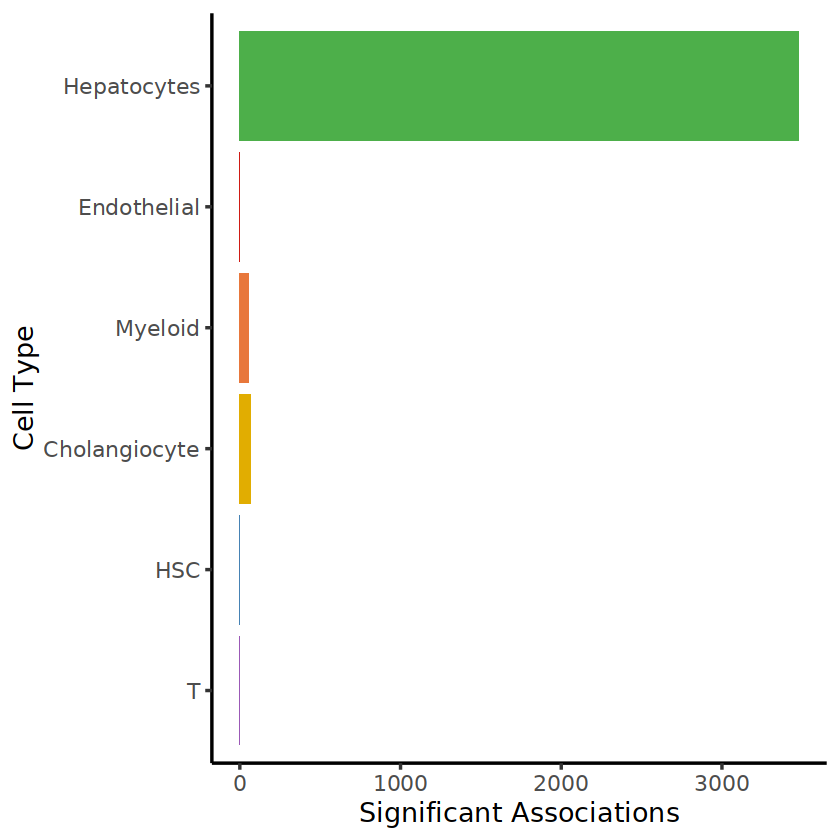

In [10]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")

# TSS

In [ ]:
# ON HPC

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.cis_qtl.txt.gz') 
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/TSS/outs/Endothelial.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/TSS/outs/Endothelial.cis_qtl_pairs.chr.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv')
#   - ex: /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/TSS/outs/Endothelial.cis_qtl_pairs.chr.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/TSS/outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/TSS/outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        if (!file.exists(paste0(indir,cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'))) {
            next
        }
        chr.res <- vroom(paste0(indir,cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        ct.res <- rbind(ct.res, chr.res)
        gc()
    }
    
    write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.tsv'),
           sep='\t', col.names=T, row.names=F, quote=F)
    write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.sig.tsv'),
               sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
    message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
    
    summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'H3K27acQTL.summary.tsv'),
           quote=F, row.names=F, col.names=T, sep='\t')

In [1]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/TSS/outs/H3K27acQTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<int>,<int>
Endothelial,105649,33,411121303,1653
Hepatocytes,262182,370,1018657805,19948
T,16377,1,61851248,29
HSC,45585,0,176151028,0
Cholangiocyte,63689,0,249920083,0
Myeloid,112699,14,437918020,697
NK,9380,0,35207383,0
B,13278,0,49740291,0
Bulk,379410,442,1493678770,23448


In [4]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [5]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

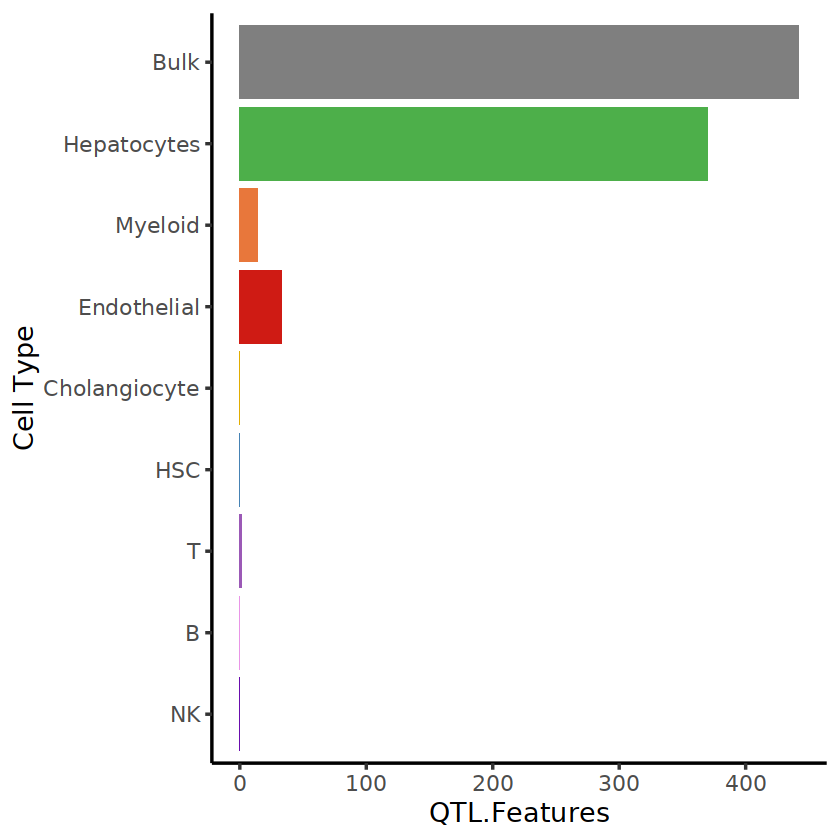

In [6]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='QTL.Features', y='Cell Type') + theme(legend.position="none")

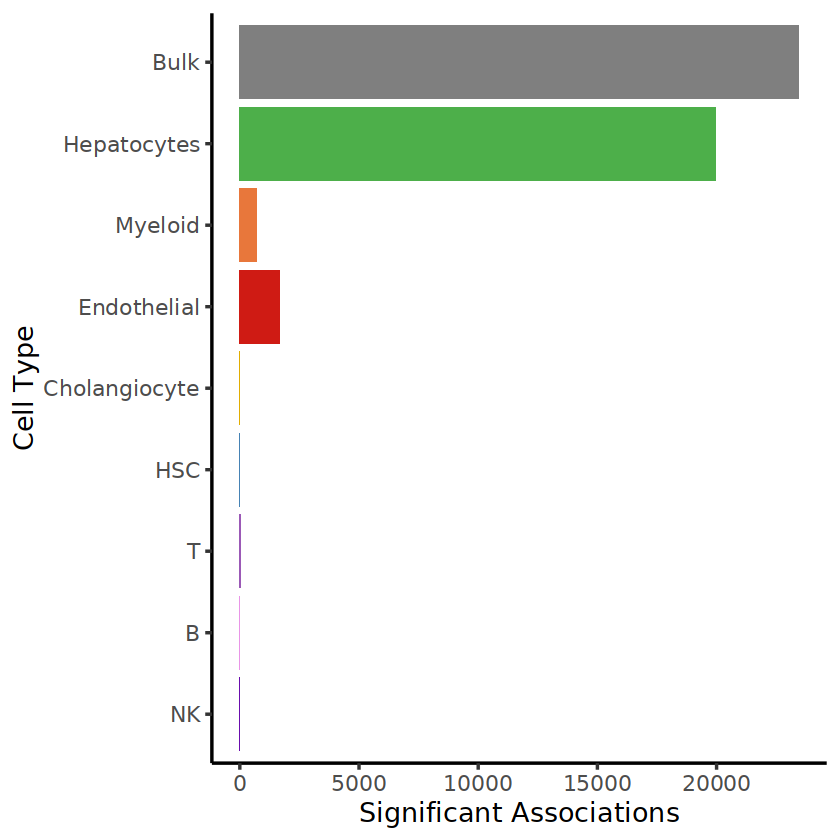

In [8]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")